# Fake News Detection - Model Training & Visualization Pipeline

This comprehensive notebook trains, evaluates, and visualizes machine learning models on the WELFake news dataset.

### Workflow Outline:
1. **Environment Setup & Imports**: Standard DS libraries, NLP tools (`nltk`), ML classifiers (`sklearn`), and visualizers (`seaborn`, `matplotlib`, `plotly`, `wordcloud`).
2. **Robust Path Resolution**: Automatic dataset & output directory locator.
3. **Data Ingestion & Cleaning**: Missing value imputation, text column concatenation, and target validation.
4. **Exploratory Data Analysis (EDA)**: Class balance countplot & interactive donut distribution chart.
5. **NLP Preprocessing**: Tokenization, regex cleaning, stopword removal, and cached lemmatization.
6. **Word Clouds**: Visual frequency comparison of Fake News vs Genuine/Real News vocabulary.
7. **Train-Test Split & TF-IDF Vectorization**: Unigram & Bigram feature extraction.
8. **Model Training & Benchmark**:
   - **Multinomial Naive Bayes**
   - **Logistic Regression**
   - **Passive Aggressive Classifier**
9. **Visual Evaluation**:
   - Seaborn Confusion Matrix Heatmaps
   - ROC Curves & AUC Metric Comparison
   - Cross-Model Performance Bar Chart (Accuracy & F1)
10. **Interactive Inference**: Single-article test predictor with confidence score.
11. **Artifact Export**: Serializing the champion model and vectorizer for the FastAPI backend.


## 1. Imports & Configuration


In [1]:
import os
import re
import sys
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

# NLP - NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-Learn Classifiers
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier

# Scikit-Learn Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

# Plotting Aesthetics
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")
print("[+] All libraries loaded successfully!")


[+] All libraries loaded successfully!


## 2. Paths & Directory Setup


In [2]:
# Locate dataset across multiple possible kernel working directories
candidate_paths = [
    os.path.join(os.getcwd(), "data", "Dataset.csv"),
    os.path.join(os.getcwd(), "fake-news-ml", "data", "Dataset.csv"),
    os.path.abspath(os.path.join(os.getcwd(), "..", "data", "Dataset.csv")),
    os.path.abspath(os.path.join(os.getcwd(), "..", "fake-news-ml", "data", "Dataset.csv")),
]

DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])
MODELS_DIR = os.path.join(os.path.dirname(os.path.dirname(DATA_PATH)), "models")
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"[*] Dataset location : {os.path.abspath(DATA_PATH)} (Found: {os.path.exists(DATA_PATH)})")
print(f"[*] Models directory : {os.path.abspath(MODELS_DIR)}")


[*] Dataset location : d:\pg\web_app\ai\fake news detection\fake-news-ml\data\Dataset.csv (Found: True)
[*] Models directory : d:\pg\web_app\ai\fake news detection\fake-news-ml\models


## 3. Dataset Ingestion & Missing Value Cleaning


In [3]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print(f"Initial dataset shape: {df.shape}")
display(df.head())

# Missing value check
print("\n--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# Impute missing values with empty strings
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')

# Combine title and text into a unified 'content' feature
df['content'] = df['title'] + ' ' + df['text']

# Clean invalid rows (missing labels or empty content)
df = df[df['label'].notnull()]
df['label'] = df['label'].astype(int)
df = df[df['content'].str.strip() != '']

print("\n--- Cleaned Dataset ---")
print(f"Cleaned dataset shape: {df.shape}")
print(f"Target distribution:\n{df['label'].value_counts()}")


Initial dataset shape: (72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1



--- Missing Values Before Cleaning ---
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

--- Cleaned Dataset ---
Cleaned dataset shape: (72134, 5)
Target distribution:
label
1    37106
0    35028
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA) & Visualizations
Let's visualize the target class distribution with both a countplot and an interactive donut chart.


C:\Users\ssiya\AppData\Local\Temp\ipykernel_3224\4283902318.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['label'], palette=palette)
findfont: Failed to find font weight semibold for Arial, now using 700.


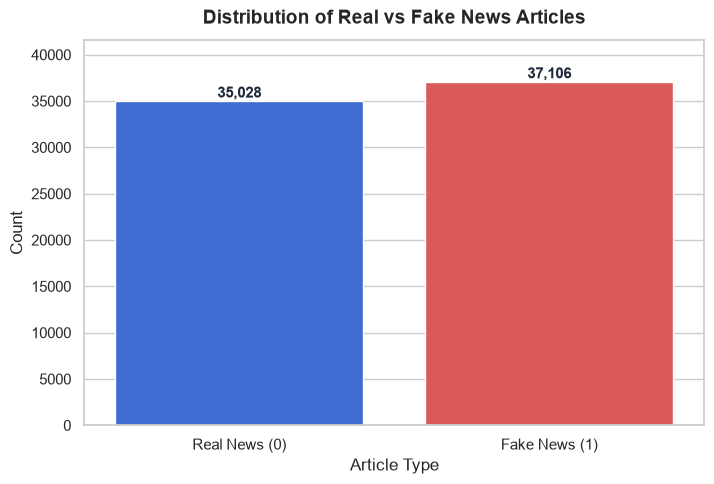

In [4]:
# 1. Target Class Distribution Bar Plot
plt.figure(figsize=(8, 5))
palette = ['#2563eb', '#ef4444']  # Blue for Real (0), Red for Fake (1)
ax = sns.countplot(x=df['label'], palette=palette)
plt.xlabel("Article Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Real vs Fake News Articles", fontsize=14, fontweight='bold', pad=12)

# Annotate counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='semibold', color='#1e293b')

plt.xticks([0, 1], ["Real News (0)", "Fake News (1)"], fontsize=11)
plt.ylim(0, max(df['label'].value_counts()) * 1.12)
plt.show()


In [5]:
# 2. Interactive Pie / Donut Chart
label_counts = df['label'].value_counts()
label_names = ['Real News (0)' if idx == 0 else 'Fake News (1)' for idx in label_counts.index]

fig = px.pie(
    names=label_names,
    values=label_counts.values,
    hole=0.55,
    title="Proportion of Real vs Fake News Articles",
    color_discrete_sequence=['#2563eb', '#ef4444']
)
fig.update_traces(textposition='inside', textinfo='percent+label', marker=dict(line=dict(color='#ffffff', width=2)))
fig.update_layout(title_font_size=16, font=dict(family='Arial', size=13))
fig.show()


## 5. NLP Preprocessing Pipeline
Applies text lowercasing, removal of URLs, punctuation and special symbols, stopword removal, and lemmatization (with memoization cache for high throughput).


In [6]:
# Initialize NLTK components
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
lemma_cache = {}

url_pattern = re.compile(r'https?://\S+|www\.\S+|<.*?>')
clean_pattern = re.compile(r'[^a-z\s]')

def fast_lemmatize(w):
    if w not in lemma_cache:
        lemma_cache[w] = lemmatizer.lemmatize(w)
    return lemma_cache[w]

def preprocess_text(text: str) -> str:
    if not isinstance(text, str) or not text:
        return ''
    text = url_pattern.sub(' ', text.lower())
    text = clean_pattern.sub(' ', text)
    words = text.split()
    tokens = [fast_lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# Test preprocessor on a sample
sample = "Breaking News! The president announced new economic measures today at https://news.example.com."
print("Sample raw:     ", sample)
print("Sample cleaned: ", preprocess_text(sample))


Sample raw:      Breaking News! The president announced new economic measures today at https://news.example.com.
Sample cleaned:  breaking news president announced new economic measure today


In [7]:
# Apply preprocessing to entire dataset
print("[*] Preprocessing text across all articles...")
t0 = time.time()
df['cleaned_content'] = [preprocess_text(t) for t in df['content']]
print(f"[+] Preprocessing finished in {time.time() - t0:.2f} seconds.")
print(f"Vocabulary cache size: {len(lemma_cache):,} unique lemmas.")


[*] Preprocessing text across all articles...
[+] Preprocessing finished in 10.62 seconds.
Vocabulary cache size: 199,828 unique lemmas.


## 6. Word Clouds (Fake vs Real News)
Word clouds visualize the most prominent words in each class, revealing linguistic markers characteristic of sensationalist fake news versus factual genuine news.


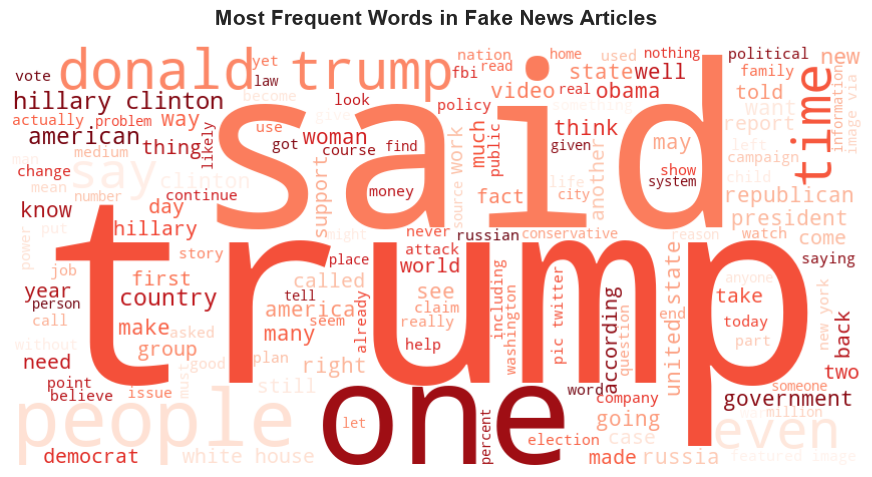

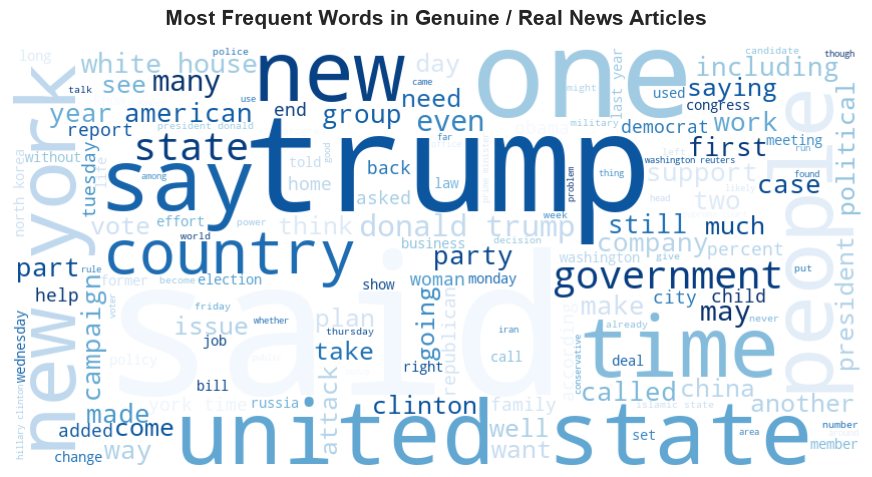

In [8]:
def plot_wordcloud(text, title, colormap='Blues'):
    wc = WordCloud(
        width=850,
        height=420,
        background_color='white',
        colormap=colormap,
        max_words=150,
        contour_width=1,
        contour_color='steelblue'
    ).generate(text)
    
    plt.figure(figsize=(11, 5.5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=15, fontweight='bold', pad=15)
    plt.show()

# Sample up to 5,000 articles per category for fast and balanced wordcloud rendering
fake_corpus = ' '.join(df[df['label'] == 1]['cleaned_content'].dropna().sample(n=min(5000, sum(df['label'] == 1)), random_state=42))
real_corpus = ' '.join(df[df['label'] == 0]['cleaned_content'].dropna().sample(n=min(5000, sum(df['label'] == 0)), random_state=42))

# 1. Fake News Word Cloud
plot_wordcloud(fake_corpus, 'Most Frequent Words in Fake News Articles', colormap='Reds')

# 2. Genuine/Real News Word Cloud
plot_wordcloud(real_corpus, 'Most Frequent Words in Genuine / Real News Articles', colormap='Blues')


## 7. Train-Test Split & TF-IDF Vectorization


In [9]:
# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_content'],
    df['label'],
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)

print(f"Train samples: {len(X_train):,} | Test samples: {len(X_test):,}")

# Fit TF-IDF Vectorizer (Unigram + Bigram, top 50,000 features)
print("[*] Vectorizing text data with TF-IDF...")
t0 = time.time()
tfidf_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"[+] TF-IDF transform completed in {time.time() - t0:.2f}s. Matrix shape: {X_train_tfidf.shape}")


Train samples: 57,707 | Test samples: 14,427
[*] Vectorizing text data with TF-IDF...
[+] TF-IDF transform completed in 44.84s. Matrix shape: (57707, 50000)


## 8. Model Training & Evaluation
We train and benchmark three complementary ML models:
1. **Multinomial Naive Bayes (MNB)**: Fast probabilistic baseline.
2. **Logistic Regression (LR)**: Well-calibrated linear model.
3. **Passive Aggressive Classifier (PAC)**: High-speed margin-based online classifier optimized for sparse text.


In [10]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    "Passive Aggressive Classifier": PassiveAggressiveClassifier(max_iter=1000, random_state=42, C=0.5)
}

results = {}

for name, model in models.items():
    print("=" * 65)
    print(f"[*] Training {name}...")
    t_start = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - t_start
    
    # Predictions
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["Real (0)", "Fake (1)"])
    
    # Probability / Decision Score for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, "decision_function"):
        dfunc = model.decision_function(X_test_tfidf)
        y_scores = (dfunc - dfunc.min()) / (dfunc.max() - dfunc.min() + 1e-9)
    else:
        y_scores = None
        
    auc_val = roc_auc_score(y_test, y_scores) if y_scores is not None else 0.0
    
    results[name] = {
        "model": model,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "auc": auc_val,
        "y_scores": y_scores,
        "confusion_matrix": cm,
        "report": report,
        "train_time": train_time
    }
    
    print(f"[+] {name} trained in {train_time:.2f}s")
    print(f"[+] Accuracy: {acc * 100:.2f}% | F1-Score: {f1 * 100:.2f}% | AUC: {auc_val:.4f}")
    print("\nClassification Report:")
    print(report)


d:\pg\web_app\ai\fake news detection\fake-news-ml\venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


[*] Training Multinomial Naive Bayes...
[+] Multinomial Naive Bayes trained in 0.05s
[+] Accuracy: 87.87% | F1-Score: 87.86% | AUC: 0.9517

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.89      0.85      0.87      7006
    Fake (1)       0.87      0.90      0.88      7421

    accuracy                           0.88     14427
   macro avg       0.88      0.88      0.88     14427
weighted avg       0.88      0.88      0.88     14427

[*] Training Logistic Regression...
[+] Logistic Regression trained in 0.62s
[+] Accuracy: 95.48% | F1-Score: 95.48% | AUC: 0.9901

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.96      0.95      0.95      7006
    Fake (1)       0.95      0.96      0.96      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427

[*] Training Passive Aggress

## 9. Visualizing Confusion Matrices


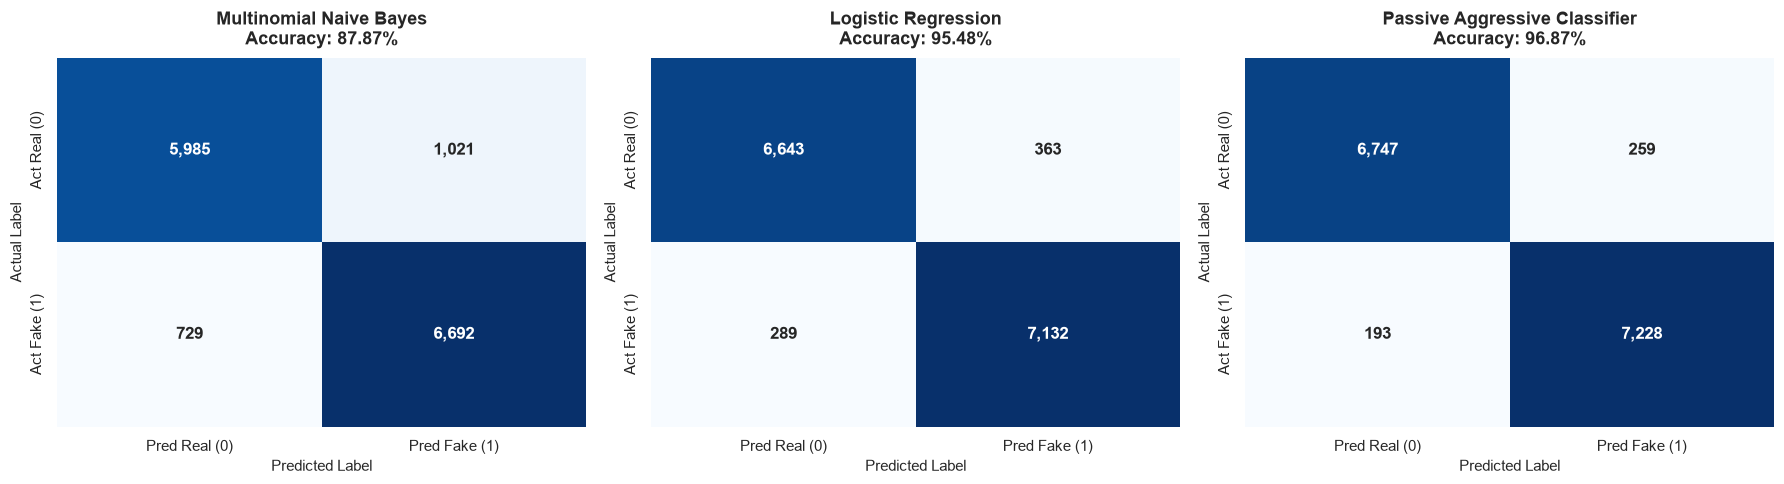

In [11]:
# Confusion Matrix Heatmaps for all models side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, res) in enumerate(results.items()):
    sns.heatmap(
        res["confusion_matrix"],
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        ax=axes[idx],
        xticklabels=["Pred Real (0)", "Pred Fake (1)"],
        yticklabels=["Act Real (0)", "Act Fake (1)"],
        annot_kws={"size": 12, "weight": "bold"}
    )
    axes[idx].set_title(f"{name}\nAccuracy: {res['accuracy'] * 100:.2f}%", fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel("Predicted Label", fontsize=11)
    axes[idx].set_ylabel("Actual Label", fontsize=11)

plt.tight_layout()
plt.show()


## 10. ROC Curves & AUC Analysis
The Receiver Operating Characteristic (ROC) curve evaluates diagnostic ability across varying decision thresholds.


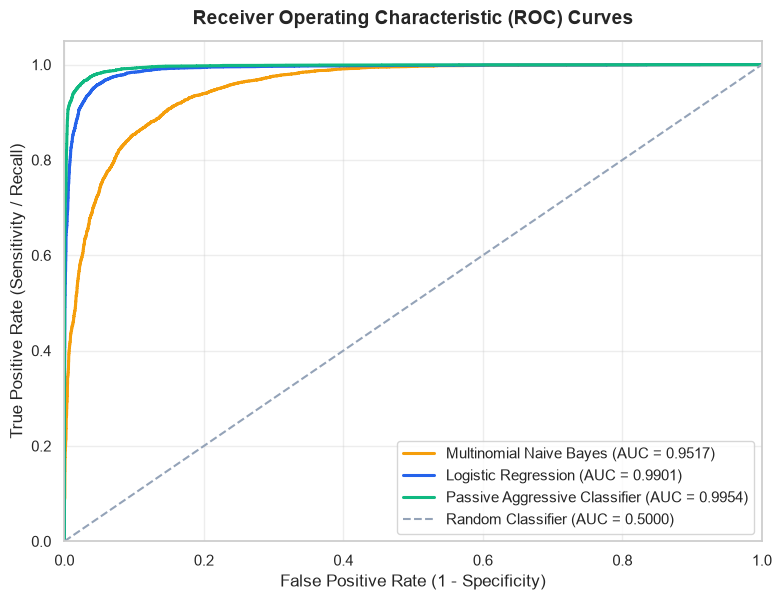

In [12]:
plt.figure(figsize=(9, 6.5))
colors = ['#f59e0b', '#2563eb', '#10b981']

for (name, res), color in zip(results.items(), colors):
    if res["y_scores"] is not None:
        fpr, tpr, _ = roc_curve(y_test, res["y_scores"])
        plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})", color=color, lw=2.2)

plt.plot([0, 1], [0, 1], color="#94a3b8", linestyle="--", lw=1.5, label="Random Classifier (AUC = 0.5000)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=14, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=11, frameon=True)
plt.grid(True, alpha=0.35)
plt.show()


## 11. Cross-Model Performance Comparison (Bar Chart)
Visualizing comparative Accuracy, F1-Score, and AUC side-by-side.


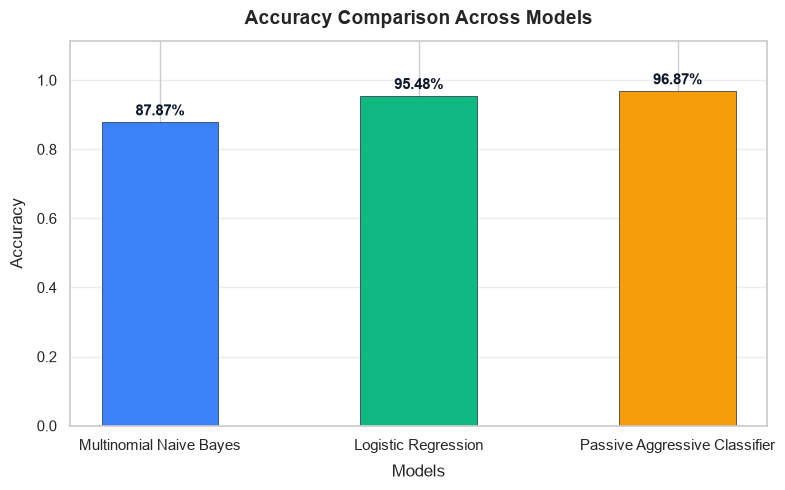

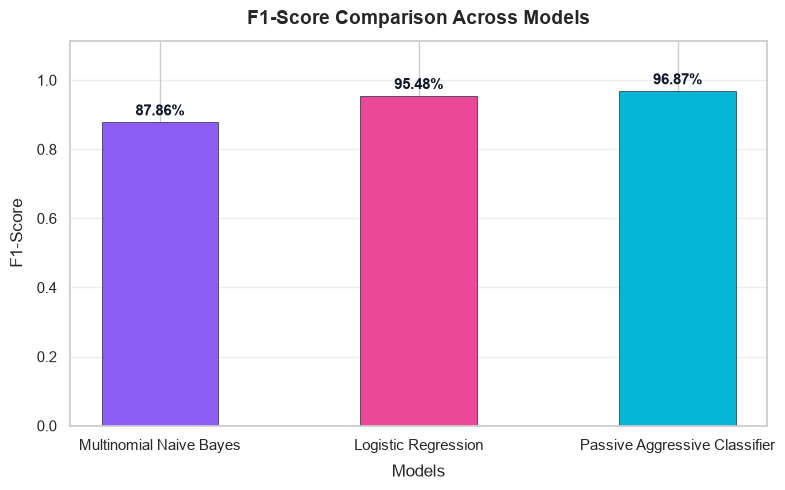

In [13]:
def plot_histogram(metric_values, model_names, metric_name, color_palette=None):
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = color_palette or ['#3b82f6', '#10b981', '#f59e0b']
    bars = ax.bar(model_names, metric_values, color=colors[:len(model_names)], width=0.45, edgecolor='#1e293b', linewidth=0.5)
    
    plt.xlabel('Models', fontsize=12, labelpad=8)
    plt.ylabel(metric_name, fontsize=12, labelpad=8)
    plt.title(f'{metric_name} Comparison Across Models', fontsize=14, fontweight='bold', pad=12)
    plt.ylim(0, max(metric_values) * 1.15)
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.01,
            f'{yval * 100:.2f}%',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='#0f172a'
        )
    
    plt.grid(axis='y', alpha=0.35)
    plt.show()

# 1. Accuracy comparison
model_names = list(results.keys())
accuracy_vals = [res['accuracy'] for res in results.values()]
plot_histogram(accuracy_vals, model_names, 'Accuracy')

# 2. F1-Score comparison
f1_vals = [res['f1_score'] for res in results.values()]
plot_histogram(f1_vals, model_names, 'F1-Score', color_palette=['#8b5cf6', '#ec4899', '#06b6d4'])


## 12. Inference Test: Input Random Text & Predict
Interactive test function allowing you to enter custom news articles and inspect prediction output.


In [14]:
def predict_news(text: str, model_name: str = 'Passive Aggressive Classifier'):
    cleaned = preprocess_text(text)
    vec = tfidf_vectorizer.transform([cleaned])
    model = results[model_name]["model"]
    pred = model.predict(vec)[0]
    label_str = "FAKE NEWS (1)" if pred == 1 else "GENUINE / REAL NEWS (0)"
    
    # Confidence estimation
    if hasattr(model, "predict_proba"):
        conf = model.predict_proba(vec)[0][pred] * 100
    elif hasattr(model, "decision_function"):
        score = model.decision_function(vec)[0]
        conf = (1 / (1 + np.exp(-abs(score)))) * 100
    else:
        conf = 100.0
        
    print("=" * 60)
    print(f"Input Text:   {text[:120]}...")
    print(f"Model Used:   {model_name}")
    print(f"Prediction:   {label_str}")
    print(f"Confidence:   {conf:.2f}%")
    print("=" * 60)
    return pred, conf

# Test with sample fake headline
predict_news("SHOCKING: Secret lab discovered aliens controlling world governments from Antarctica!")

# Test with sample genuine headline
predict_news("The federal reserve announced a 25 basis point reduction in interest rates following monthly inflation data.")


Input Text:   SHOCKING: Secret lab discovered aliens controlling world governments from Antarctica!...
Model Used:   Passive Aggressive Classifier
Prediction:   FAKE NEWS (1)
Confidence:   91.75%
Input Text:   The federal reserve announced a 25 basis point reduction in interest rates following monthly inflation data....
Model Used:   Passive Aggressive Classifier
Prediction:   FAKE NEWS (1)
Confidence:   61.50%


(np.int64(1), np.float64(61.495246887662056))

## 13. Exporting Winning Model & Vectorizer


In [ ]:
# Determine champion model based on highest test accuracy
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_result = results[best_name]

print(f"[★] Winning Champion Model: {best_name}")
print(f"[★] Accuracy: {best_result['accuracy'] * 100:.2f}%")
print(f"[★] F1 Score: {best_result['f1_score'] * 100:.2f}%")
print(f"[★] AUC:      {best_result['auc']:.4f}")

# File paths for artifacts
model_export_path = os.path.join(MODELS_DIR, "fake_news_model.pkl")
vectorizer_export_path = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")

# Serialize with Joblibx
joblib.dump(best_result["model"], model_export_path)
joblib.dump(tfidf_vectorizer, vectorizer_export_path)

print(f"\n[+] Saved model to:      {os.path.abspath(model_export_path)}")
print(f"[+] Saved vectorizer to: {os.path.abspath(vectorizer_export_path)}")
print(f"[+] Model file size:     {os.path.getsize(model_export_path) / 1024:.2f} KB")
print(f"[+] Vectorizer size:     {os.path.getsize(vectorizer_export_path) / 1024 / 1024:.2f} MB")
print("\n[✔] Ready for FastAPI server deployment!")


[★] Winning Champion Model: Passive Aggressive Classifier
[★] Accuracy: 96.87%
[★] F1 Score: 96.87%
[★] AUC:      0.9954

[+] Saved model to:      d:\pg\web_app\ai\fake news detection\fake-news-ml\models\fake_news_model.pkl
[+] Saved vectorizer to: d:\pg\web_app\ai\fake news detection\fake-news-ml\models\tfidf_vectorizer.pkl
[+] Model file size:     391.73 KB
[+] Vectorizer size:     1.94 MB

[✔] Ready for FastAPI server deployment!
